# LAB 2 - Linear Regression Part II
### INFO 251: Applied Machine Learning

* Author: Simón Ramírez Amaya
* Date: Jan 28, 2026

## Helper Functions

#### Execute these cells to helper functions and modules into memory. No need to write any code here.

In [144]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.ticker import FuncFormatter

In [145]:
def sample_schooling_income(
    n,
    mu_x=14.0,
    mu_y=60000.0,
    sigma_x=2.5,
    sigma_y=15000.0,
    rho=0.7,
    break_1=12.0,
    break_2=16.0,
    jump_1=0,
    jump_2=0,
    random_state=None
):
    """
    Generate a random sample of size n from the schooling-income distribution
    with discontinuities in the conditional mean.

    Parameters
    ----------
    n : int
        Sample size.
    mu_x, mu_y : float
        Means of schooling and baseline income.
    sigma_x, sigma_y : float
        Standard deviations of schooling and income noise.
    rho : float
        Correlation used for slope of conditional mean.
    break_1, break_2 : float
        Schooling levels where income jumps occur.
    jump_1, jump_2 : float
        Magnitude of the jumps at the break points.
    random_state : int or None
        Seed for reproducibility.

    Returns
    -------
    X : ndarray of shape (n,)
        Simulated schooling values.
    Y : ndarray of shape (n,)
        Simulated income values.
    """

    rng = np.random.default_rng(random_state)

    # Step 1: sample schooling
    X = rng.normal(loc=mu_x, scale=sigma_x, size=n)

    # Step 2: compute conditional mean
    slope = rho * (sigma_y / sigma_x)
    m_X = mu_y + slope * (X - mu_x)
    m_X += jump_1 * (X >= break_1)
    m_X += jump_2 * (X >= break_2)

    # Step 3: sample income conditional on schooling
    Y = rng.normal(loc=m_X, scale=sigma_y, size=n)

    return X, Y

# Exercise 1

In [148]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm
from matplotlib.ticker import FuncFormatter

def ols_repeated_sampling(
    n=500,
    m=10000,
    mu_x=14.0,
    mu_y=60000.0,
    sigma_x=2.5,
    sigma_y=15000.0,
    rho=0.7,
    break_1=None,
    break_2=None,
    jump_1=0,
    jump_2=0,
    x_min=5.0,
    x_max=20.0,
    seed=None
):
    """
    Monte Carlo study of OLS slope estimator with optional discontinuities.
    Uses exact analytical BLP for plotting.

    Parameters
    ----------
    n, m : int
        Sample size per replication, number of Monte Carlo replications.
    mu_x, mu_y, sigma_x, sigma_y, rho : float
        Parameters of bivariate normal.
    break_1, break_2 : float or None
        Locations of discontinuities.
    jump_1, jump_2 : float
        Magnitude of discontinuities.
    x_min, x_max : float
        Plotting range.
    seed : int or None
        Random seed.
    """

    if seed is not None:
        np.random.seed(seed)

    x_grid = np.linspace(x_min, x_max, 200)

    # ---- Monte Carlo OLS sampling ----

    # Use these arrays to keep track of the slopes and fitted lines. 
    slopes = []
    fitted_lines = []

    for _ in range(m):
        X,y = sample_schooling_income(
            n=n,
            mu_x=mu_x,
            mu_y=mu_y,
            sigma_x=sigma_x,
            sigma_y=sigma_y,
            rho=rho,
            break_1=break_1,
            break_2=break_2,
            jump_1=jump_1,
            jump_2=jump_2,
        )

        # YOUR CODE HERE: OLS fit using statsmodels.api.OLS (don't forget to add the constant and use HC1 as cov type)
        X = sm.add_constant(X)
        model = sm.OLS(y, X).fit()
        beta0_hat, beta1_hat = model.params
        slopes.append(beta1_hat)
        fitted_lines.append(beta0_hat + beta1_hat * x_grid)

    slopes = np.array(slopes)

    
    # ---- Analytical BLP ----
    # Base slope
    beta1_base = rho * sigma_y / sigma_x

    # Contribution from jumps
    phi1 = norm.pdf(0) if break_1 is None else norm.pdf((break_1 - mu_x)/sigma_x)
    phi2 = norm.pdf(0) if break_2 is None else norm.pdf((break_2 - mu_x)/sigma_x)
    beta1_blp = beta1_base + (jump_1 * phi1 + jump_2 * phi2)/sigma_x

    # Beta0
    FX1 = 0.0 if break_1 is None else norm.cdf((break_1 - mu_x)/sigma_x)
    FX2 = 0.0 if break_2 is None else norm.cdf((break_2 - mu_x)/sigma_x)
    beta0_blp = mu_y + jump_1*(1 - FX1) + jump_2*(1 - FX2) - beta1_blp * mu_x

    blp_line = beta0_blp + beta1_blp * x_grid

    # ---- True CMF with discontinuities ----
    true_cmf = mu_y + beta1_base * (x_grid - mu_x)
    if break_1 is not None:
        true_cmf[x_grid >= break_1] += jump_1
    if break_2 is not None:
        true_cmf[x_grid >= break_2] += jump_2

    # ---- Plotting ----
    def thousands_formatter(val, pos):
        return f"{int(val/1000)}k"

    fig, axes = plt.subplots(1,2,figsize=(12,4), dpi=150)

    # Histogram
    axes[0].hist(slopes, bins=40, density=True, color="tab:orange", alpha=0.7)
    axes[0].axvline(beta1_blp, color="green", linestyle="--", lw=2, label="Population BLP slope")
    axes[0].set_xlabel("Estimated Slope")
    axes[0].set_ylabel("Density")
    axes[0].set_title("Sampling Distribution of OLS Slope")
    axes[0].legend()
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    # Regression lines
    for line in fitted_lines:
        axes[1].plot(x_grid, line, color="tab:orange", alpha=0.05)
    axes[1].plot(x_grid, true_cmf, color="tab:blue", lw=2.5, label="True CMF")
    axes[1].plot(x_grid, blp_line, color="green", lw=2, linestyle="--", label="Best Linear Predictor")
    axes[1].set_xlabel("Years of Completed Schooling")
    axes[1].set_ylabel("Annual Income")
    axes[1].set_ylim(20000, 100000)
    axes[1].yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    axes[1].set_title("OLS Fits with True CMF and BLP")
    axes[1].legend()
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

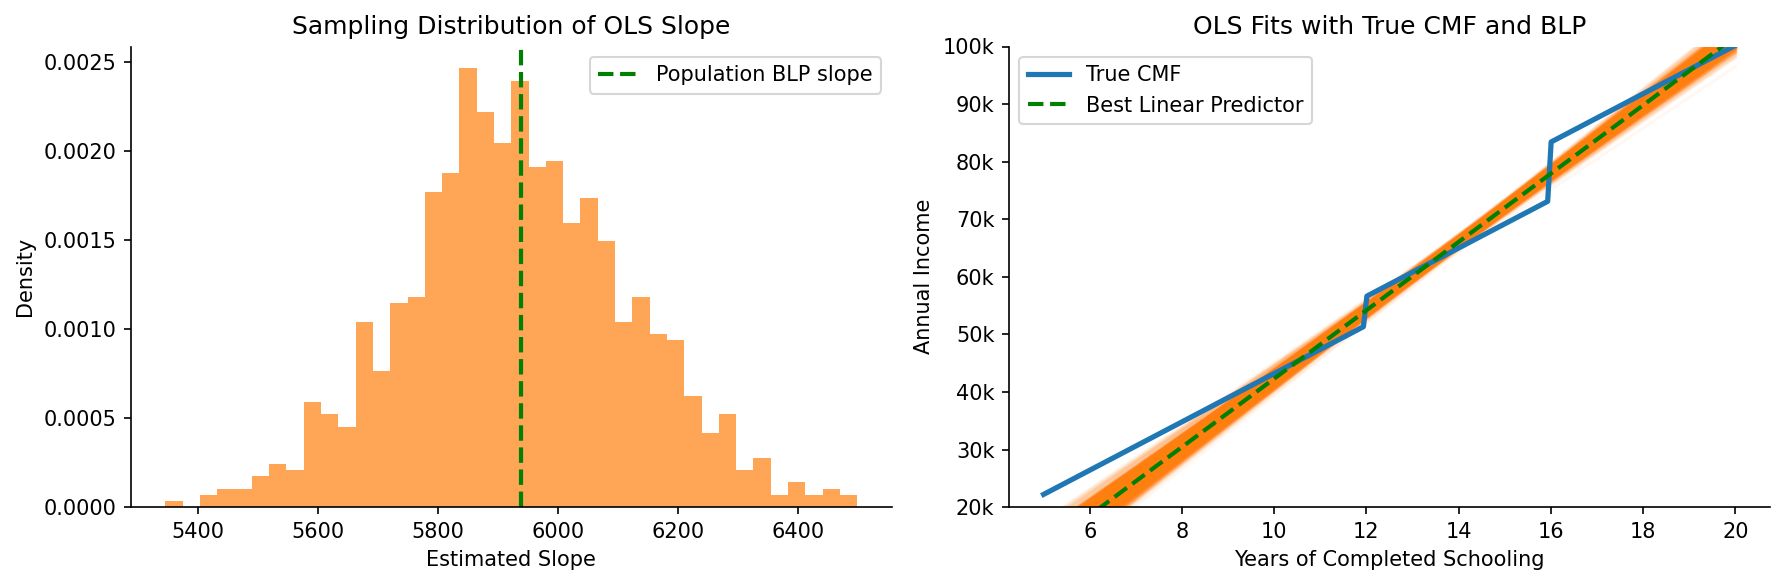

In [149]:
ols_repeated_sampling(
    n=1000,
    m=1000,
    break_1=12, 
    break_2=16,
    jump_1=5000, 
    jump_2=10000,
)

# Exercise 2

In [140]:
n = 1000

X_a, y_a = sample_schooling_income(
    n=n,
    mu_x=14.0,
    mu_y=60000.0,
    sigma_x=2.5,
    sigma_y=15000.0,
    rho=0.0,
    break_1=12.0,
    break_2=16.0,
    jump_1=0,
    jump_2=0,
)

X_b, y_b = sample_schooling_income(
    n=n,
    mu_x=14.0,
    mu_y=60000.0,
    sigma_x=2.5,
    sigma_y=15000.0,
    rho=0.7,
    break_1=12.0,
    break_2=16.0,
    jump_1=0,
    jump_2=0,
)

X_c, y_c = sample_schooling_income(
    n=n,
    mu_x=14.0,
    mu_y=60000.0,
    sigma_x=2.5,
    sigma_y=15000.0,
    rho=0.7,
    break_1=12.0,
    break_2=16.0,
    jump_1=5000,
    jump_2=10000,
)

In [141]:
# YOUR CODE HERE: use statsmodels.api.ols to estimate and display the regression tables for each sample
# Don't forget to add the constant and use HC1 as cov type

X_a = sm.add_constant(X_a)
model = sm.OLS(y_a, X_a).fit(cov_type='HC1')
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.1120
Date:                Wed, 28 Jan 2026   Prob (F-statistic):              0.738
Time:                        00:12:29   Log-Likelihood:                -11035.
No. Observations:                1000   AIC:                         2.207e+04
Df Residuals:                     998   BIC:                         2.208e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        6.19e+04   2775.869     22.300      0.000    5.65e+04    6.73e+04
x1           -64.6490    193.162     -0.335      0.738    -443.239     313.941
==============================================================================
Omnibus:                        2.110   Durbin-Watson:                   1.937
Prob(Omnibus):                  0.348   Jarque-Bera (JB):                2.154
Skew:                          -0.012   Prob(JB):                        0.341
Kurtosis:                       3.226   Cond. No.                         79.5
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [131]:
X_b = sm.add_constant(X_b)
model = sm.OLS(y_b, X_b).fit(cov_type='HC1')
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.317
Method:                 Least Squares   F-statistic:                     465.7
Date:                Wed, 28 Jan 2026   Prob (F-statistic):           4.60e-85
Time:                        00:08:36   Log-Likelihood:                -11006.
No. Observations:                1000   AIC:                         2.202e+04
Df Residuals:                     998   BIC:                         2.202e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3189.6442   2658.120      1.200      0.230   -2026.500    8405.789
x1          4073.4777    188.771     21.579      0.000    3703.045    4443.911
==============================================================================
Omnibus:                        1.309   Durbin-Watson:                   1.906
Prob(Omnibus):                  0.520   Jarque-Bera (JB):                1.381
Skew:                          -0.081   Prob(JB):                        0.501
Kurtosis:                       2.917   Cond. No.                         81.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [132]:
X_c = sm.add_constant(X_c)
model = sm.OLS(y_c, X_c).fit(cov_type='HC1')
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.482
Model:                            OLS   Adj. R-squared:                  0.481
Method:                 Least Squares   F-statistic:                     928.2
Date:                Wed, 28 Jan 2026   Prob (F-statistic):          1.14e-144
Time:                        00:08:39   Log-Likelihood:                -11049.
No. Observations:                1000   AIC:                         2.210e+04
Df Residuals:                     998   BIC:                         2.211e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -1.36e+04   2650.343     -5.132      0.000   -1.88e+04   -8401.431
x1          5678.5096    186.382     30.467      0.000    5312.765    6044.255
==============================================================================
Omnibus:                        4.597   Durbin-Watson:                   1.926
Prob(Omnibus):                  0.100   Jarque-Bera (JB):                5.431
Skew:                           0.040   Prob(JB):                       0.0662
Kurtosis:                       3.352   Cond. No.                         78.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""